In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random as random
from collections import deque

### Color Schema

- Gray -> Open Path (1)
- Black -> Wall (0-2)
- Yellow -> Quicksand (3)
- Red -> Hole (4)
- Blue -> Gate(5)

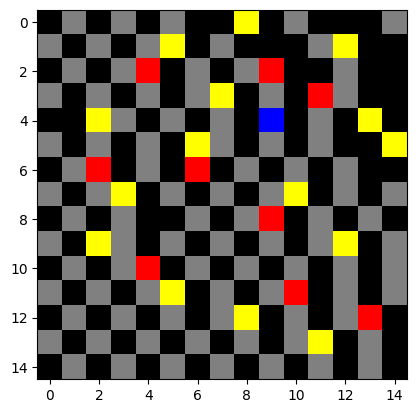

In [2]:


grid_map = np.array([
    [1, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 2, 1, 0, 1, 1, 1, 0, 2, 1, 1],
    [1, 0, 1, 0, 3, 1, 0, 1, 0, 3, 1, 1, 0, 1, 1],
    [0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 3, 0, 1, 1],
    [1, 1, 2, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1, 2, 1],
    [0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2],
    [1, 0, 3, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 1, 1],
    [0, 1, 0, 2, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 0],
    [1, 0, 1, 0, 1, 1, 0, 1, 0, 3, 1, 0, 1, 0, 1],
    [0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0],
    [1, 0, 1, 0, 3, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 2, 1, 0, 1, 0, 3, 1, 0, 1, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 0, 3, 1],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
])
colors = ['grey', 'black', 'yellow', 'red', 'blue']
cmap = ListedColormap(colors)
plt.imshow(grid_map, cmap = cmap, vmin = 0, vmax = 4)

- Too Many Blocked Paths

#### Grid Class


In [3]:
class Grid:
    #------------------------------------------------------ Static Variables
    obstacles = [0 , 2, 3 , 4]
    passable = [1,3] #obstacles which allow passage
    #House Walls
    vertical_wall = [(1,16),(2,16),(3,16),(4,16)]
    horizontal_wall = [(4,16),(4,17),(4,18)]    
    # ----------------------------------------------------- Constructor & Getters    
    def __init__(self):
        self.grid = np.ones((20,20))
        self.gridsize = (20,20)
        
    def setGate(self,coords):
        self.coords = coords
        
    def getGrid(self):
        return self.grid
    
    def getSize(self):
        return self.gridsize
    #----------------------------------------------------- Builder Methods
    
    #Main Builder Function
    def build_grid(self):
        hole_count = 0 #A map cannot have more 2% of it as holes. 
        grid = self.getGrid()
        gridsize = self.getSize()
        #Building walls
        self.build_wall(grid)
        blocked_count = int(gridsize[0]*gridsize[1]*0.35) #35% of the grid must be blocked
        
        while blocked_count > 0 :
            #picking x and y by avoiding the edges
            x = random.randint(1,grid.shape[0]-2) 
            y = random.randint(1,grid.shape[1]-2)
            if (x,y) in Grid.vertical_wall or (x,y) in Grid.horizontal_wall:
                continue
            #making sure , the hole count does not exceed 2% of the map grid count
            obstacle = self.choose_obstacle(hole_count,gridsize)
            #Direct Neighbors
            up = (x-1,y)
            down = (x+1,y)
            left = (x,y-1)
            right = (x,y+1)
            temp = [up,down,left,right]
            check = [1 if  grid[n[0],n[1]] == 5 else 0 for n in temp]
            if sum(check) != 0:
                continue;    
            #It is prohibited for any obstacle of any kind to block the gate.
            
            if obstacle == 3:
                grid[x,y] = 3
                blocked_count-=1
            else: #obstacle NOT passable
                
                count = 0 #passable neigbors count
                passable_neigbors = [] #store all the passable neighbors
                
                for neighbor in temp:
                    if grid[neighbor[0], neighbor[1]] in Grid.passable:
                        passable_neigbors.append((neighbor[0], neighbor[1]))
                        count+=1
                    
                if count < 2:
                    #safe to add the obstacle
                    grid[x,y] = obstacle
                    blocked_count-=1
                elif count >= 2:
                    #choose a random neighbor and check the connectivity between all passable neighbors
                    chosen = random.choice(passable_neigbors)
                    state = self.bfs(grid,chosen,passable_neigbors,x,y)
                    if state:
                        #safe to add
                        grid[x,y] = obstacle
                        blocked_count-=1
        return grid
    
    #BFS for ensuring atleast 1 neighbor connectivity
    def bfs(self,grid, chosen , passable_neighbors,x,y):
        queue = deque([chosen]) #putting the source
        visited = {chosen}  #add all what we visited to this array, set of coordinates 
        #We need to temporarily block the {x,y} tile, so that the system doesn't mistake it for a path
        grid[x,y] = 2
        while queue:
            cx, cy = queue.popleft()
            
            #We need to explore its direct neighbors
            for dnx, dny in [(-1,0),(1,0),(0,-1),(0,1)]:
                #check if already visited
                if((cx+dnx,cy+dny) in visited):
                    continue
                #check if passable
                if(grid[cx+dnx,cy+dny] not in Grid.passable):
                    continue
                #check if in the neighbors 
                if((cx+dnx,cy+dny) in passable_neighbors):
                    grid[x,y] = 1 #Unblock it
                    return True
                #neither of both, we add it as visited and we add it to the queue
                queue.append((cx+dnx,cy+dny))
                visited.add((cx+dnx,cy+dny))
            
        grid[x,y] = 1
        return False
    
    #Building walls around the map border
    def build_wall(self,grid):
        #Creating walls around the map
        grid[0, :] = 2
        grid[: , 0] = 2
        grid[-1, : ] = 2
        grid[:, -1] = 2
        #building the walls
        for x,y in Grid.horizontal_wall:
            grid[x,y] = 2
        for x,y in Grid.vertical_wall:
            grid[x,y] = 2
        #Installing the gate
        coords = random.choice([(2,16),(3,16)]) #gate coords
        grid[coords[0],coords[1]] = 5

    #Choosing valid obstacle
    def choose_obstacle(self,hole_count, gridsize):
        while(True):
                obstacle = random.choice(Grid.obstacles)
                if obstacle == 4:
                    #check hole counter
                    if hole_count == int(gridsize[0]*gridsize[1]*0.02) :
                        continue
                    else:
                        hole_count+=1
                        break;
                else:
                    break
        return obstacle

    #Cleaning grid house path
    def clean_grid(self):
        #clean outside
        grid = self.getGrid()
        for x,y in Grid.vertical_wall:
            grid[x,y-1] = 1
            grid[x,y-2] = 1
            if x!=4: #to avoid removing part of the horizontal wall, the part below clears the house from inside
                grid[x,y+1] = 1
                grid[x,y+2] = 1
        for x,y in Grid.horizontal_wall: 
            grid[x+1,y] = 1
            grid[x+2,y] = 1
        grid[Grid.vertical_wall[-1][0]+1, Grid.horizontal_wall[0][1]-1] = 1 #cleaning the direct diagonal of the house vertex
    #Sets a random passable spawn point for the player
    def set_spawn(self):
        grid = self.getGrid()
        while True:
            x = random.randint((grid.shape[0] // 2), grid.shape[0] - 2) #Can spawn at the lower half
            y = random.randint(1, grid.shape[1] - 2)
            if (x, y) in Grid.vertical_wall or (x, y) in Grid.horizontal_wall:
                continue
            if grid[x, y] in Grid.passable:
                return (x, y)

    #Validates that a path exists between spawn and the gate (value 5) via BFS
    def validate_spawn_to_gate(self, spawn):
        grid = self.getGrid()
        queue = deque([spawn])
        visited = {spawn}
        while queue:
            x, y = queue.popleft()
            # if we reached the gate
            if grid[x, y] == 5:
                return True
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]: #moves to the neighbors (direct NOT DIAGONAL)
                nx, ny = x + dx, y + dy
                if (nx, ny) in visited:
                    continue
                if grid[nx, ny] in Grid.passable or grid[nx, ny] == 5:
                    visited.add((nx, ny))
                    queue.append((nx, ny))
        #No path found -> 
        return False

    #Main Generator Function, You will use this when generating 
    def generate_grid(self):
        while True:
            # Reset grid on each attempt
            self.grid = np.ones((20, 20))
            self.build_grid()
            self.clean_grid()
            spawn = self.set_spawn()
            if self.validate_spawn_to_gate(spawn):
                print(f"Spawn Point: {spawn}")
                break
    
    #Grid Visualizer
    def showGrid(self):
        colors = ['black', 'grey', 'black', 'yellow', 'red', 'blue']
        cmap = ListedColormap(colors)
        plt.imshow(self.getGrid(), cmap = cmap, vmin = 0, vmax = 5)

Spawn Point: (14, 18)


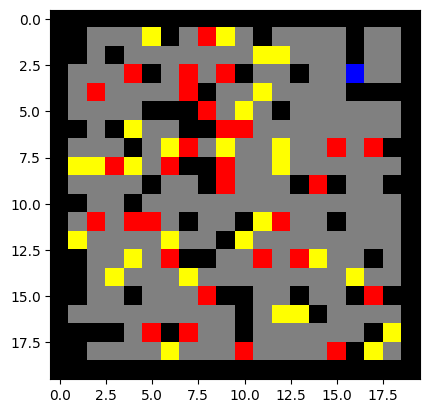

In [4]:
gridObj = Grid()
gridObj.generate_grid()
gridObj.showGrid()